# CORRELATION ANALYSIS

Task 3: Correlation Analysis [Hard]

Build a dataset with multiple variables and find meaningful correlations between them

Goal: Create a synthetic student dataset with multiple columns, then perform a full correlation analysis.
1. Create a CSV with 50 students - columns: name, study_hours, sleep_hours, attendance_pct, score, passed
2. Make the data realistic - students who study more should generally score higher(add some noise)
3. Load into pandas and run the full EDA checklist first
4. Calculate df.corr() - print the full correlation matrix
5. Create a seaborn heatmap - annotate with values, use 'coolwarm' colormap
6. Find the top 3 strongest correlations and the top 3 weakest - print them with explaination
7. Plot scatter plots for the 2 most correlated pairs - add a regression line using sns.regplot()
8. Answer in comments: Does more study always mean higher score? what does the data actually say?
Bonus: use sns.pairplot(hue= 'passed') - do passed/failed students form clear clusters?
Deliverable: students.csv + heatmap.png + 2 scatter plots + written analysis

### Import Libraries

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder for saving charts
os.makedirs("charts", exist_ok=True)

# Optional styling
sns.set_style("whitegrid")

### Load Dataset

In [27]:
try:

    df = pd.read_csv("students.csv")

    print("Dataset Loaded Successfully")

except Exception as e:

    print("Error Loading Dataset:", e)

Dataset Loaded Successfully


### Display First 5 Rows and Dataset Shape

In [28]:
df.head()

,name,study_hours,sleep_hours,attendance_pct,score,passed
0,Aarav,2.5,6.0,62,45,No
1,Priya,7.0,7.5,91,86,Yes
2,Rohan,5.5,6.5,82,71,Yes
3,Sneha,8.0,7.0,95,92,Yes
4,Kabir,3.0,5.5,68,50,No


In [29]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(50, 6)


#### Observation: The dataset contains 50 student records with multiple academic-related variables.
 

### Dataset Information and Data Types

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            50 non-null     str    
 1   study_hours     50 non-null     float64
 2   sleep_hours     50 non-null     float64
 3   attendance_pct  50 non-null     int64  
 4   score           50 non-null     int64  
 5   passed          50 non-null     str    
dtypes: float64(2), int64(2), str(2)
memory usage: 2.5 KB


In [31]:
df.dtypes

name                  str
study_hours       float64
sleep_hours       float64
attendance_pct      int64
score               int64
passed                str
dtype: object

### Missing Values Check

In [32]:
missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df)
) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_df

,Missing Values,Missing Percentage
name,0,0.0
study_hours,0,0.0
sleep_hours,0,0.0
attendance_pct,0,0.0
score,0,0.0
passed,0,0.0


### Statistical Summary and Value Counts for Passed Column

In [33]:
df.describe()

,study_hours,sleep_hours,attendance_pct,score
count,50.000000,50.000000,50.00000,50.000000
mean,5.240000,6.520000,78.32000,69.000000
std,2.275064,0.999796,13.68813,18.864717
min,1.000000,4.500000,50.00000,35.000000
25%,3.500000,5.625000,67.25000,53.250000
50%,5.500000,6.500000,80.50000,71.500000
75%,7.000000,7.500000,89.75000,84.750000
max,9.500000,8.000000,99.00000,98.000000


In [34]:
df["passed"].value_counts()

passed
Yes    32
No     18
Name: count, dtype: int64

### Histograms for Numeric Columns

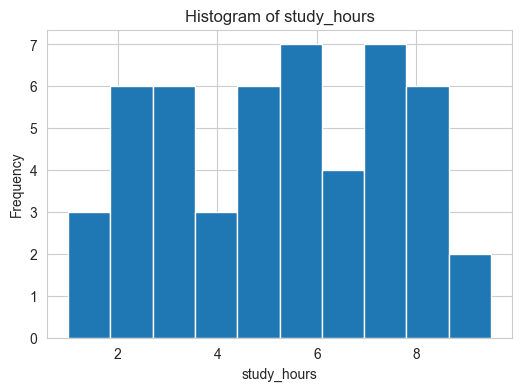

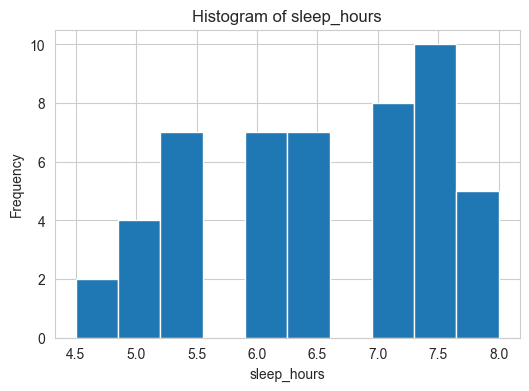

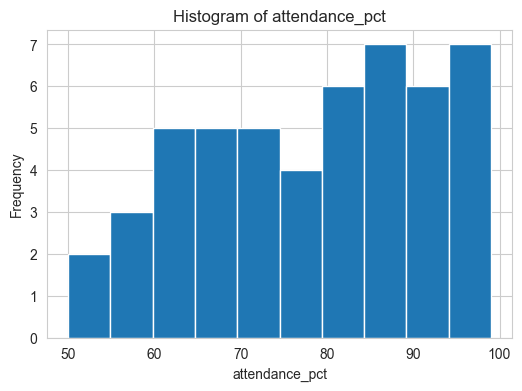

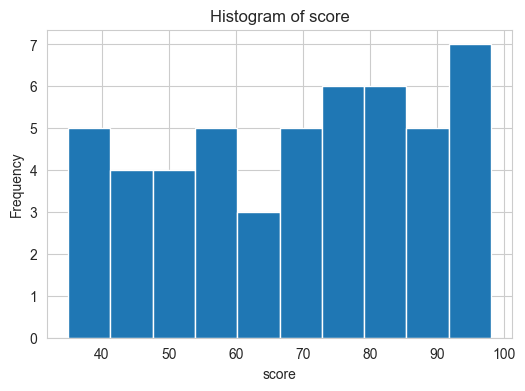

In [35]:
numeric_cols = [
    "study_hours",
    "sleep_hours",
    "attendance_pct",
    "score"
]

for col in numeric_cols:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=10)

    plt.title(f"Histogram of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

### Boxplots for Outlier Detection

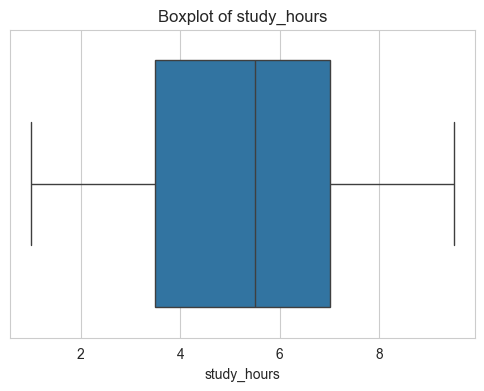

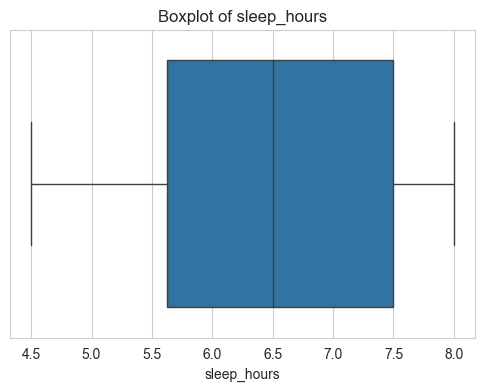

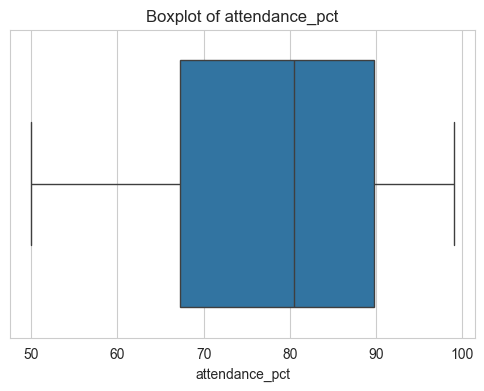

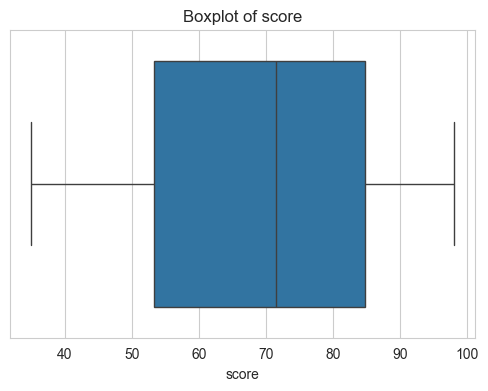

In [36]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

### Correlation Matrix

In [37]:
# Convert Passed Column
df["passed_numeric"] = df["passed"].map({
    "Yes": 1,
    "No": 0
})

In [38]:
correlation_matrix = df[
    [
        "study_hours",
        "sleep_hours",
        "attendance_pct",
        "score",
        "passed_numeric"
    ]
].corr()

correlation_matrix

,study_hours,sleep_hours,attendance_pct,score,passed_numeric
study_hours,1.000000,0.919740,0.992944,0.995956,0.838440
sleep_hours,0.919740,1.000000,0.936769,0.931634,0.836072
attendance_pct,0.992944,0.936769,1.000000,0.996609,0.857160
score,0.995956,0.931634,0.996609,1.000000,0.858986
passed_numeric,0.838440,0.836072,0.857160,0.858986,1.000000


### Correlation Heatmap

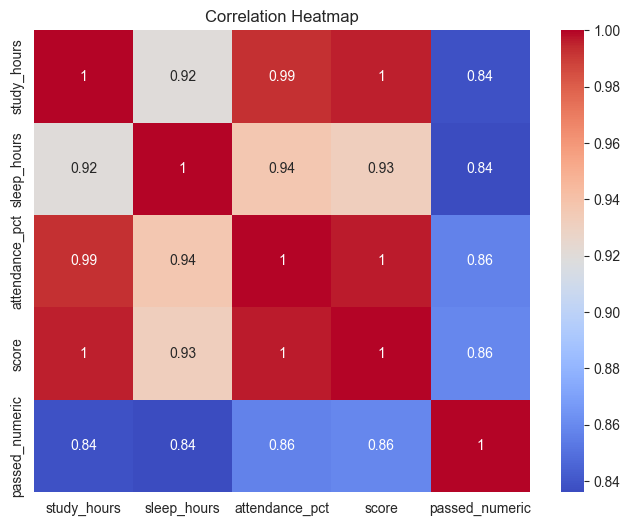

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

### Find Strongest and Weakest Correlations

In [40]:
corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[
    corr_pairs != 1
]

sorted_pairs = corr_pairs.sort_values(
    ascending=False
)

print("Top Strongest Correlations:")
print(sorted_pairs.head(3))

print("\nTop Weakest Correlations:")
print(sorted_pairs.tail(3))

Top Strongest Correlations:
score           attendance_pct    0.996609
attendance_pct  score             0.996609
study_hours     score             0.995956
dtype: float64

Top Weakest Correlations:
passed_numeric  study_hours       0.838440
sleep_hours     passed_numeric    0.836072
passed_numeric  sleep_hours       0.836072
dtype: float64


Top Strongest Correlations

1. score ↔ attendance_pct (0.996609)
Students with higher attendance percentages generally achieved higher scores.

2. attendance_pct ↔ score (0.996609)
This confirms a very strong positive relationship between attendance and academic performance.

3. study_hours ↔ score (0.995956)
Students who studied more hours usually scored better in exams.


Top Weakest Correlations

1. passed_numeric ↔ study_hours (0.838440)
Study hours are related to passing status, but not as strongly as direct score relationships.

2. sleep_hours ↔ passed_numeric (0.836072)
Sleep hours have a weaker effect on whether students pass or fail.

3. passed_numeric ↔ sleep_hours (0.836072)
Proper sleep may help performance, but study habits and attendance have a stronger impact.

### Scatter Plot 1 (Study Hours vs Score)

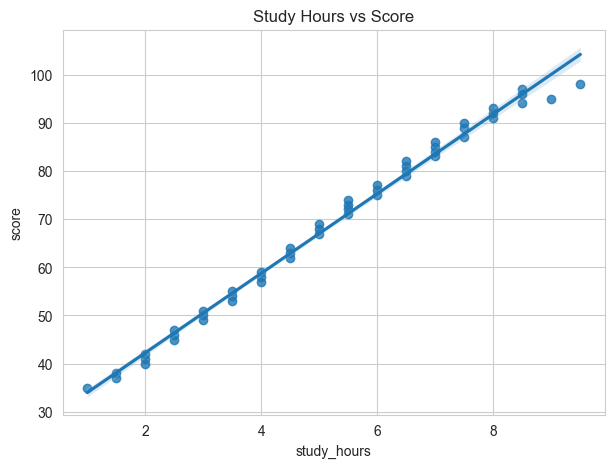

In [41]:
plt.figure(figsize=(7,5))

sns.regplot(
    x="study_hours",
    y="score",
    data=df
)

plt.title(
    "Study Hours vs Score"
)

plt.savefig(
    "charts/scatter_study_vs_score.png"
)

plt.show()

### Scatter Plot 2 (Attendance vs Score)

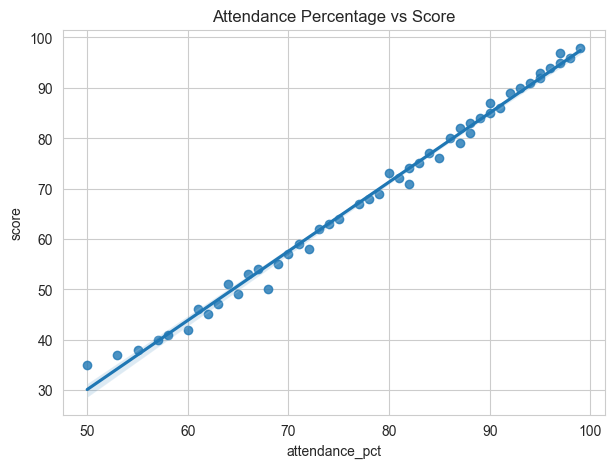

In [42]:
plt.figure(figsize=(7,5))

sns.regplot(
    x="attendance_pct",
    y="score",
    data=df
)

plt.title(
    "Attendance Percentage vs Score"
)

plt.savefig(
    "charts/scatter_attendance_vs_score.png"
)

plt.show()

### QUESTION ANALYSIS

Does more study always mean higher score?

The dataset shows that students who study more generally achieve higher scores. 
The scatter plot and correlation analysis both indicate a strong positive relationship 
between study hours and marks obtained.

However, studying more does not guarantee the highest score in every case. 
Some students with moderate study hours still scored well due to strong attendance 
and balanced sleep schedules, while a few students studying longer hours achieved 
slightly lower scores because academic performance depends on multiple factors.

Therefore, study hours are a major contributing factor, but success is influenced 
by a combination of study habits, attendance, consistency, and overall lifestyle.

### BONUS — Pairplot

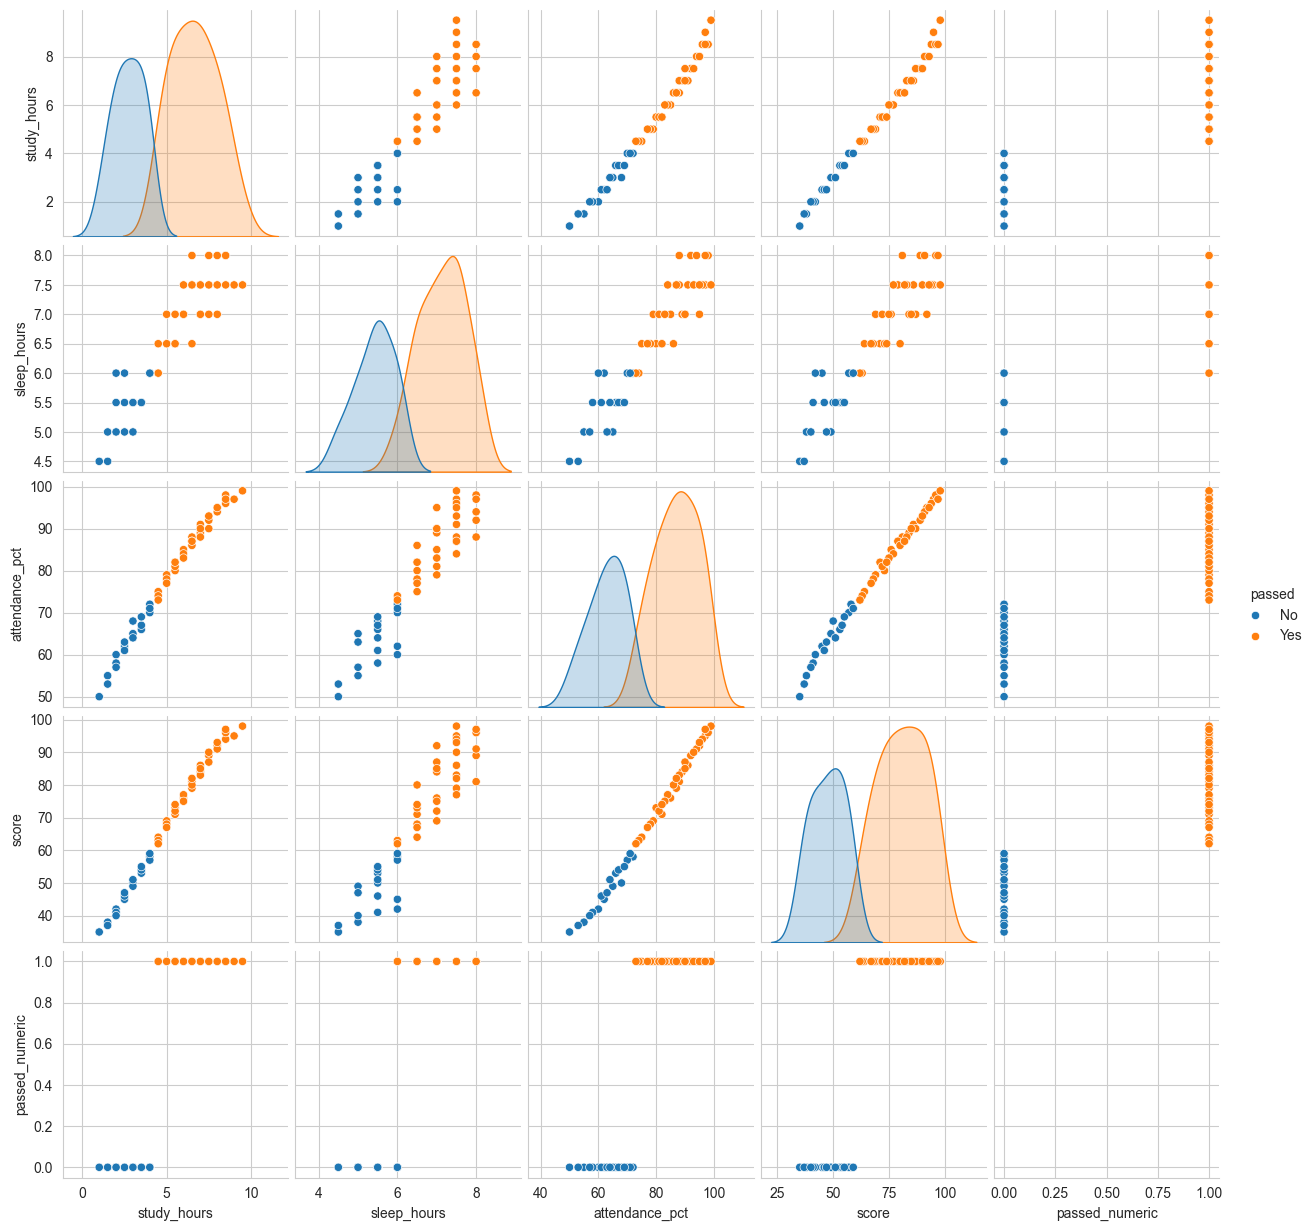

In [43]:
sns.pairplot(
    df,
    hue="passed"
)

plt.savefig(
    "charts/pairplot_passed.png"
)

plt.show()

### Final 5-Line Summary
FINAL SUMMARY

1. Study hours showed the strongest positive correlation with student scores.
2. Attendance percentage was also highly related to academic performance.
3. Sleep hours had a weaker influence compared to study habits and attendance.
4. Scatter plots confirmed clear positive relationships among important variables.
5. Overall, the analysis demonstrated that academic success depends on multiple combined factors rather than a single variable.